# Imports

In [2]:
import os, sys
import pandas as pd

# Setup path to project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    render_table2_accuracy,
    render_table2_runtime,
    run_and_plot_errors_vary_m,
    plot_convergence
)

from Tests.CPU.testing_helpers import (
    RADIAL_METHODS,
    run_NM_radial_sweep,
    run_bc_quad_radial_sweep,
    render_NM_radial_accuracy,
    render_NM_radial_runtime,
    render_bc_quad_radial_accuracy,
    render_bc_quad_radial_runtime,
    plot_radial_accuracy_vs_M,
    plot_radial_accuracy_vs_N,
    plot_radial_runtime_vs_M,
    plot_bc_quad_radial_accuracy,
    plot_bc_quad_comparison_vs_M,
    plot_convergence,
)

# Parameters

In [3]:
# ── Edit these freely ────────────────────────────────────────────────────────

N_VALS  = [32, 64, 128, 256, 512]   # angular point counts
M_VALS  = [32, 64, 128, 256, 512]   # radial  point counts
N_FIXED = 128                        # fixed N used in the BC/quad sweep

# Subset of RADIAL_METHODS to run (comment out any you want to skip)
ACTIVE_METHODS = RADIAL_METHODS      # all five by default

MUTE = False   # True = suppress per-case print output

In [4]:
# Run Tests

In [5]:
print("Running N × M sweep...")
df_nm = run_NM_radial_sweep(
    N_values=N_VALS,
    M_values=M_VALS,
    methods=ACTIVE_METHODS,
    bc_choice=1,    # Dirichlet
    quad_rule=1,    # Trapezoidal
    mute=MUTE,
)
print("Done.")

print(f"Running BC × quadrature sweep  (N = {N_FIXED})...")
df_bq = run_bc_quad_radial_sweep(
    N_fixed=N_FIXED,
    M_values=M_VALS,
    methods=ACTIVE_METHODS,
    mute=MUTE,
)
print("Done.")

Running N × M sweep...

── Uniform Radial ──
  N=  32, M=  32 | L2_rel=1.098e-05 | t=0.101s
  N=  32, M=  64 | L2_rel=2.661e-06 | t=0.001s
  N=  32, M= 128 | L2_rel=6.548e-07 | t=0.002s
  N=  32, M= 256 | L2_rel=1.624e-07 | t=0.004s
  N=  32, M= 512 | L2_rel=4.045e-08 | t=0.008s
  N=  64, M=  32 | L2_rel=1.098e-05 | t=0.001s
  N=  64, M=  64 | L2_rel=2.661e-06 | t=0.001s
  N=  64, M= 128 | L2_rel=6.548e-07 | t=0.004s
  N=  64, M= 256 | L2_rel=1.624e-07 | t=0.005s
  N=  64, M= 512 | L2_rel=4.045e-08 | t=0.018s
  N= 128, M=  32 | L2_rel=1.098e-05 | t=0.002s
  N= 128, M=  64 | L2_rel=2.661e-06 | t=0.002s
  N= 128, M= 128 | L2_rel=6.548e-07 | t=0.005s
  N= 128, M= 256 | L2_rel=1.624e-07 | t=0.011s
  N= 128, M= 512 | L2_rel=4.045e-08 | t=0.024s
  N= 256, M=  32 | L2_rel=1.098e-05 | t=0.003s
  N= 256, M=  64 | L2_rel=2.661e-06 | t=0.003s
  N= 256, M= 128 | L2_rel=6.548e-07 | t=0.007s
  N= 256, M= 256 | L2_rel=1.624e-07 | t=0.021s
  N= 256, M= 512 | L2_rel=4.045e-08 | t=0.050s
  N= 512, M=  3

# accuracy 

In [6]:
render_NM_radial_accuracy(df_nm)


render_bc_quad_radial_accuracy(df_bq)


Uniform Radial Accuracy


M,32,64,128,256,512
N,,,,,
32,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
64,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
128,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
256,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
512,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08



Nonuniform (sqrt) Accuracy


M,32,64,128,256,512
N,,,,,
32,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
64,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
128,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
256,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
512,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07



Nonuniform (∛) Accuracy


...


Nonuniform (arctan) Accuracy


M,32,64,128,256,512
N,,,,,
32,2.09e-05,5.06e-06,1.25e-06,3.09e-07,7.70e-08
64,2.09e-05,5.06e-06,1.25e-06,3.09e-07,7.70e-08
128,2.09e-05,5.06e-06,1.25e-06,3.09e-07,7.70e-08
256,2.09e-05,5.06e-06,1.25e-06,3.09e-07,7.70e-08
512,2.09e-05,5.06e-06,1.25e-06,3.09e-07,7.70e-08



Nonuniform (r²) Accuracy


M,32,64,128,256,512
N,,,,,
32,7.37e-05,1.79e-05,4.39e-06,1.09e-06,2.71e-07
64,7.37e-05,1.79e-05,4.39e-06,1.09e-06,2.71e-07
128,7.37e-05,1.79e-05,4.39e-06,1.09e-06,2.71e-07
256,7.37e-05,1.79e-05,4.39e-06,1.09e-06,2.71e-07
512,7.37e-05,1.79e-05,4.39e-06,1.09e-06,2.71e-07



BC × Quad Accuracy Accuracy


# runtime

In [7]:
render_NM_radial_runtime(df_nm)


render_bc_quad_radial_runtime(df_bq)


Uniform Radial Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.1011,0.0013,0.0020,0.0037,0.0076
64,9.20e-04,0.0013,0.0035,0.0048,0.0181
128,0.0018,0.0025,0.0052,0.0114,0.0244
256,0.0027,0.0032,0.0066,0.0214,0.0505
512,0.0025,0.0066,0.0176,0.0507,0.1069



Nonuniform (sqrt) Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.0022,0.0025,0.0041,0.0069,0.0058
64,7.73e-04,0.0010,0.0018,0.0039,0.0088
128,9.68e-04,0.0039,0.0036,0.0106,0.0239
256,0.0054,0.0051,0.0077,0.0217,0.0407
512,0.0026,0.0056,0.0151,0.0424,0.0855



Nonuniform (∛) Runtime (s)


...


Nonuniform (arctan) Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.0011,0.0010,0.0015,0.0037,0.0058
64,7.99e-04,0.0012,0.0020,0.0037,0.0118
128,0.0022,0.0018,0.0033,0.0080,0.0195
256,0.0014,0.0053,0.0058,0.0174,0.0491
512,0.0025,0.0051,0.0145,0.0571,0.0962



Nonuniform (r²) Runtime (s)


M,32,64,128,256,512
N,,,,,
32,8.09e-04,0.0010,0.0019,0.0028,0.0059
64,7.99e-04,0.0011,0.0019,0.0036,0.0095
128,0.0012,0.0028,0.0076,0.0123,0.0213
256,0.0020,0.0042,0.0093,0.0156,0.0570
512,0.0026,0.0055,0.0268,0.0429,0.1122



BC × Quad Runtime Runtime (s)


# Accuracy Plots

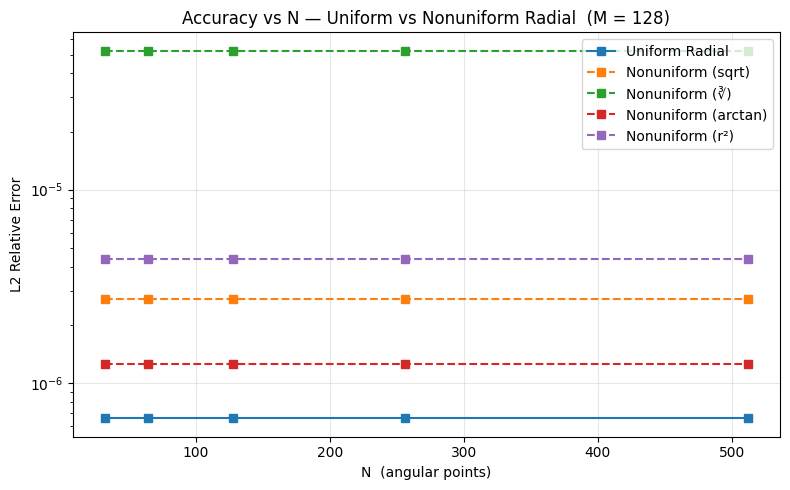

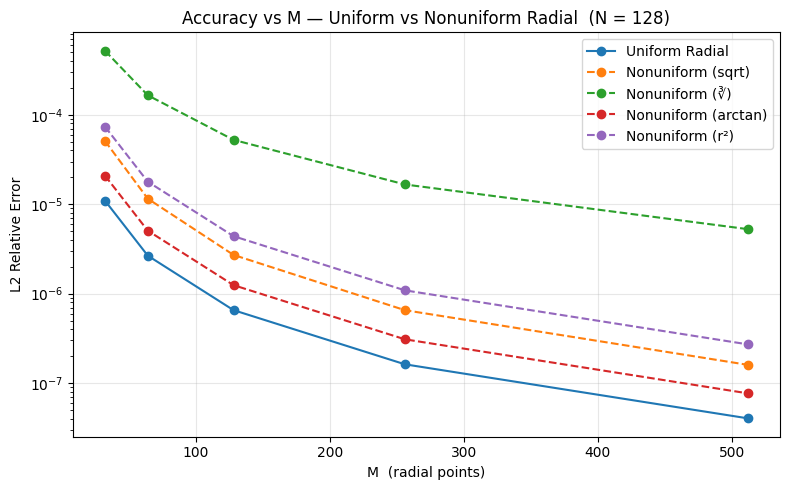

In [8]:
plot_radial_accuracy_vs_N(df_nm, M_fixed=M_VALS[len(M_VALS)//2])

plot_radial_accuracy_vs_M(df_nm, N_fixed=N_VALS[len(N_VALS)//2])


# Runtime Plots

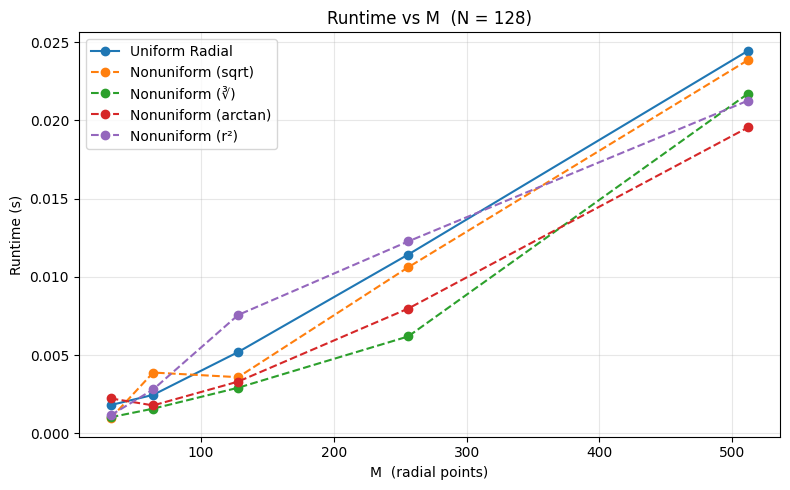

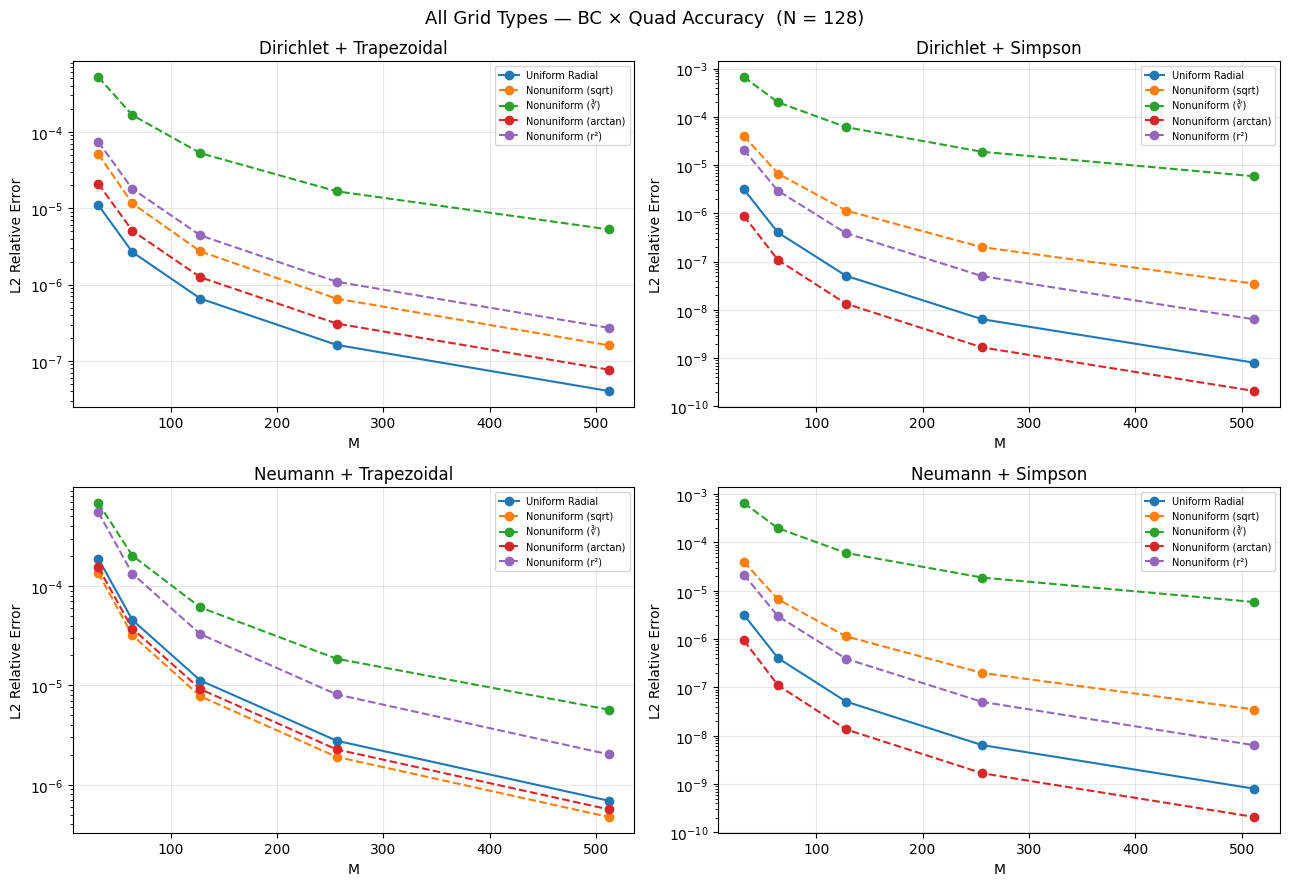

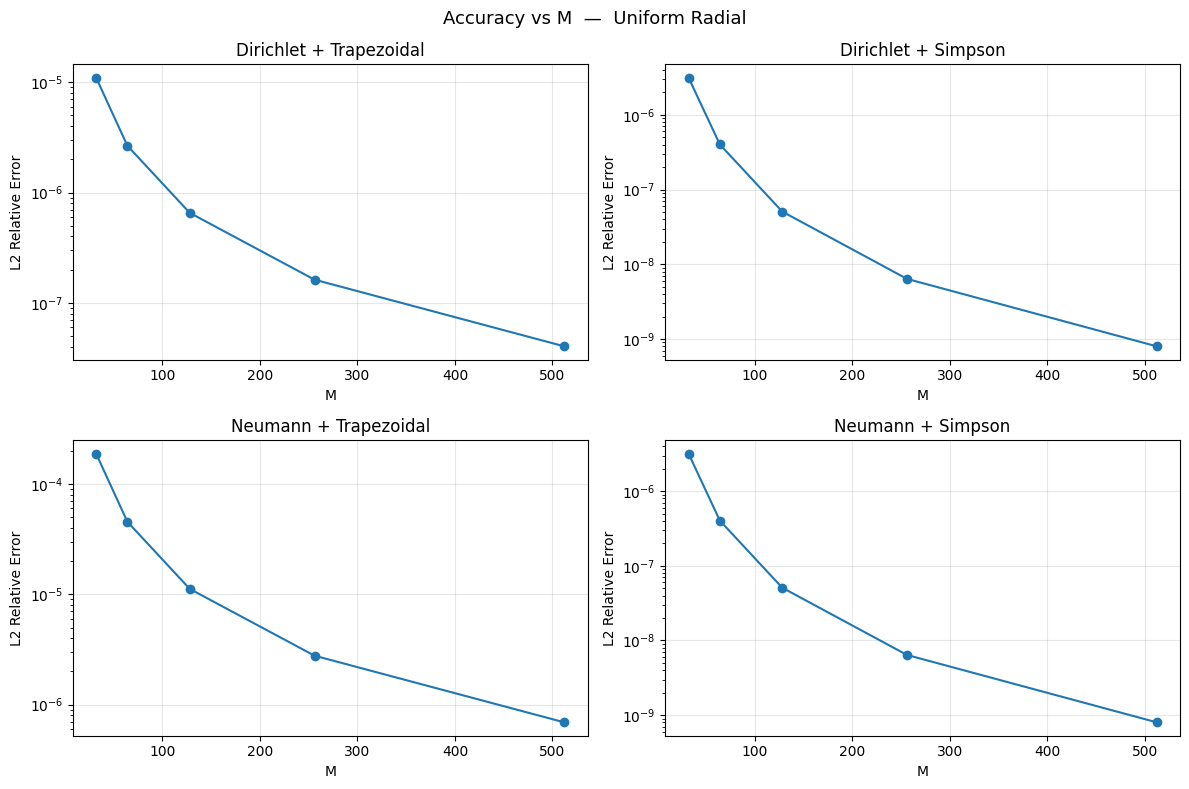

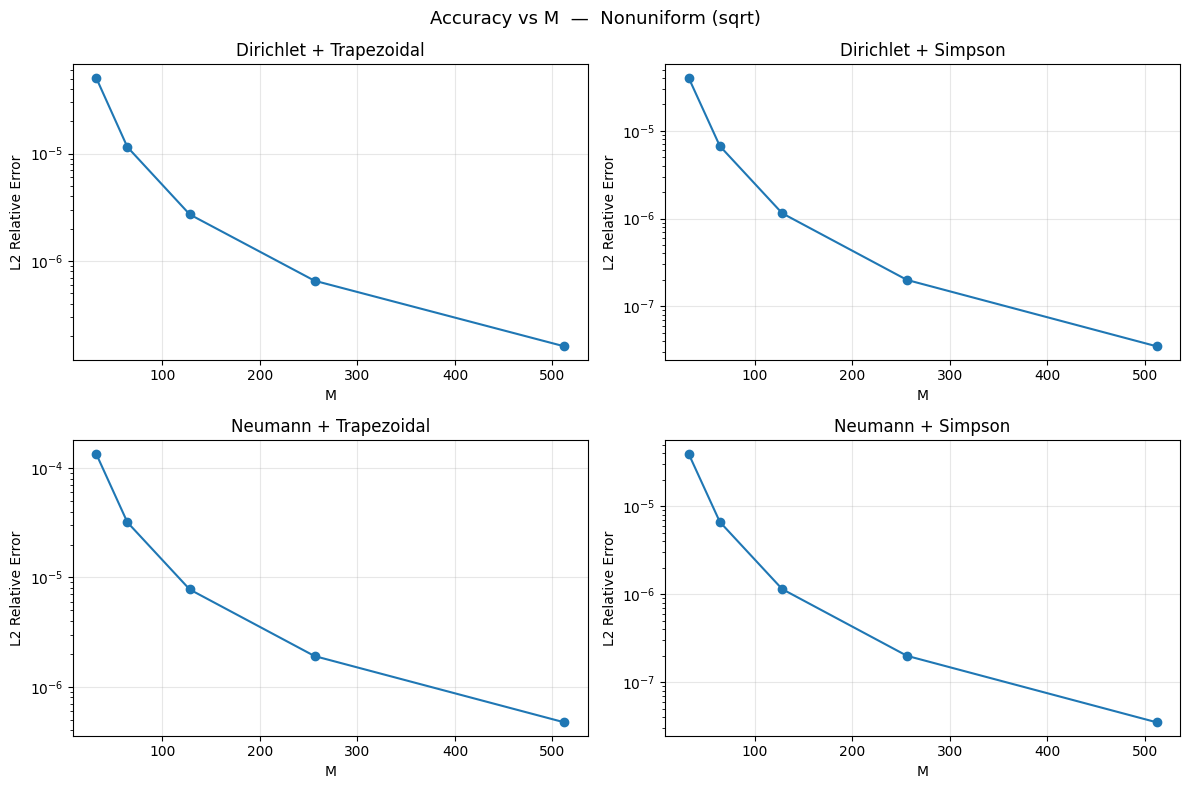

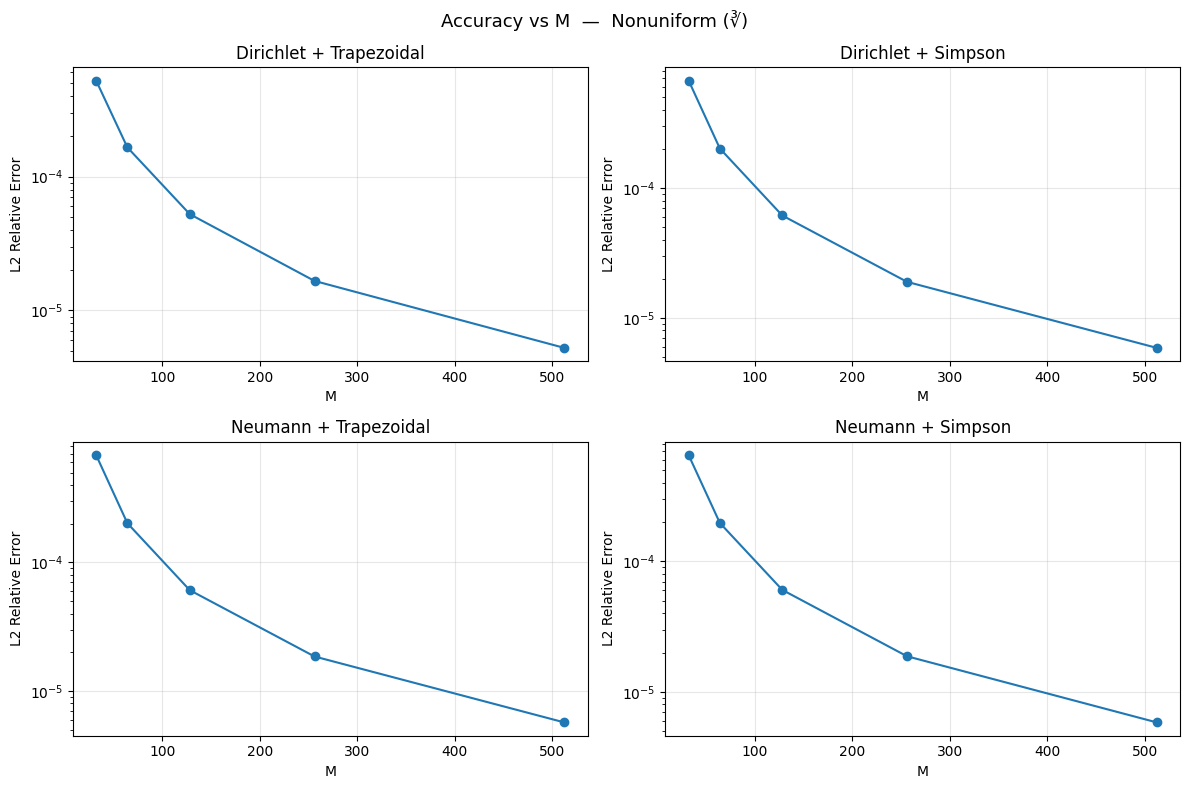

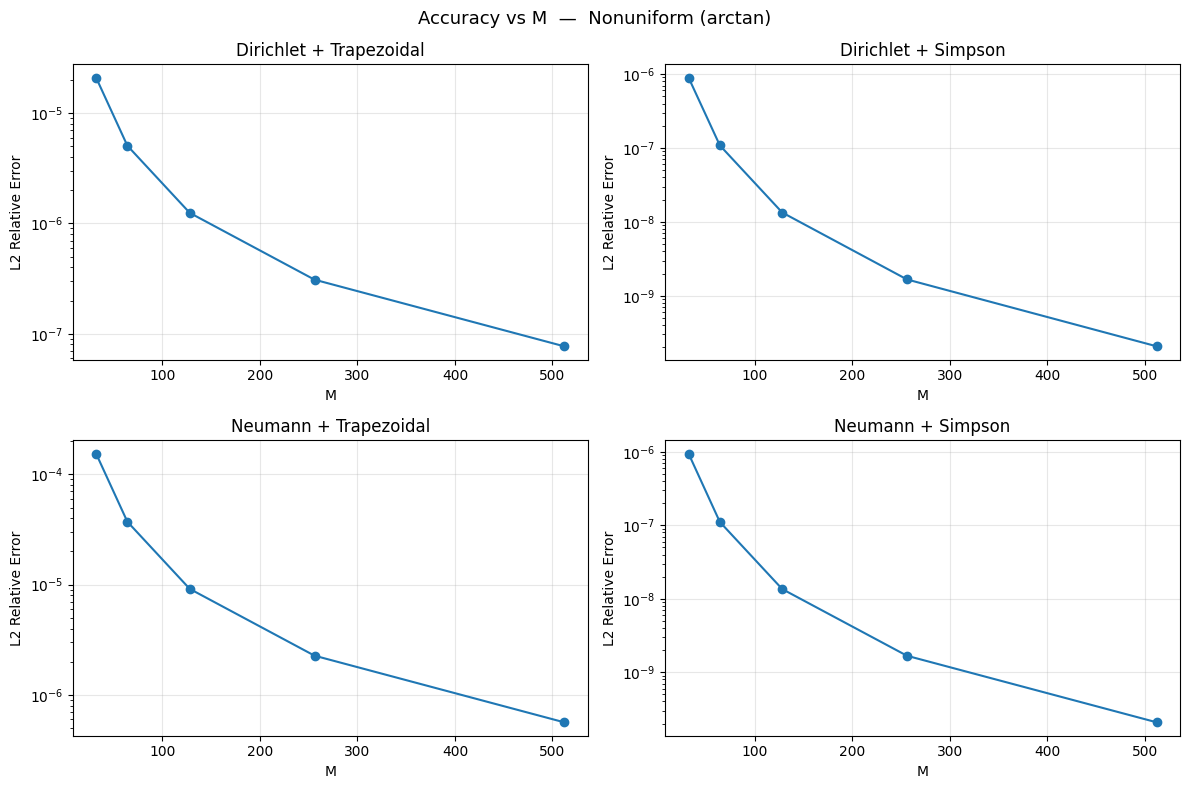

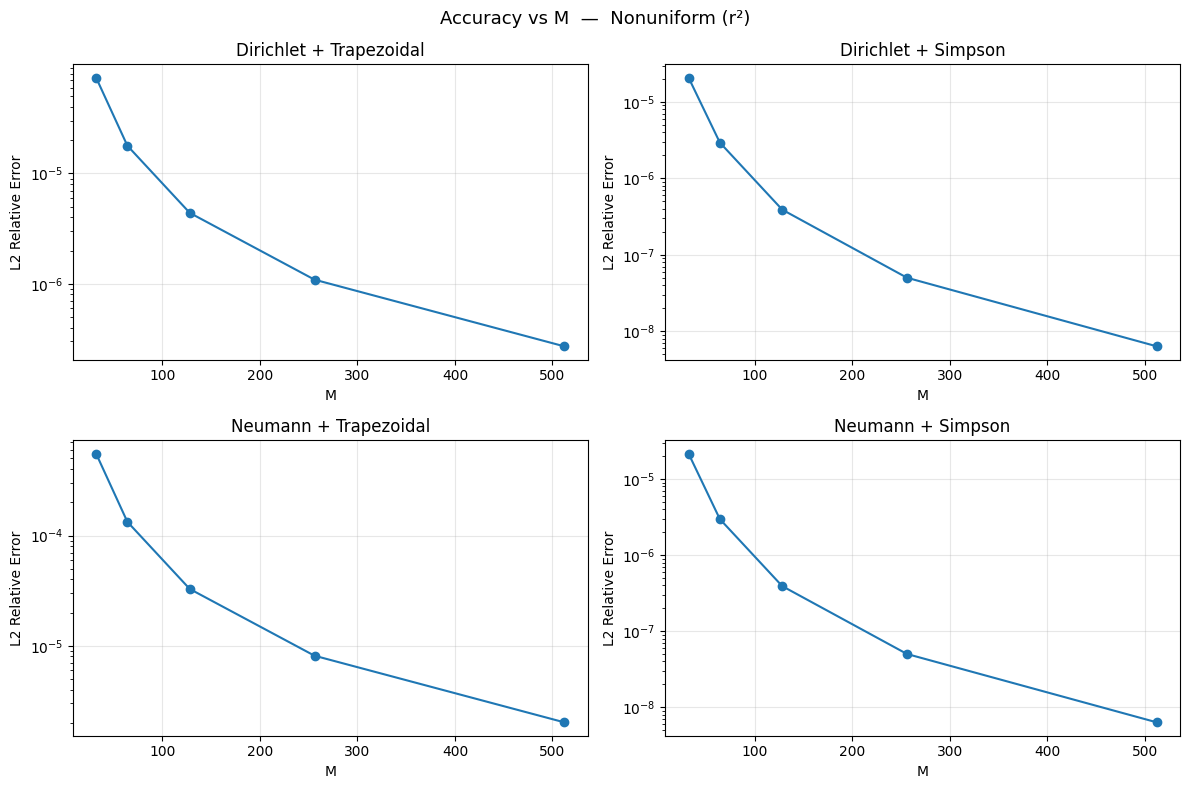

In [9]:
plot_radial_runtime_vs_M(df_nm, N_fixed=N_VALS[len(N_VALS)//2])

plot_bc_quad_comparison_vs_M(df_bq, N_fixed=N_FIXED)


for method in ACTIVE_METHODS:
    plot_bc_quad_radial_accuracy(df_bq, method["label"])